In [7]:
import numpy as np 
import pandas as pd 
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, Normalizer, RobustScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, LassoCV, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import minimize

pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', None)

# Ignorer tous les avertissements (utilisez avec précaution)
warnings.filterwarnings("ignore")

In [8]:
# Fonction pour transformer et encoder les données
# def scale_encode(x, y=0):
#     encoder = OneHotEncoder(drop='first')
#     qualitative_vars = ['Vitesse']
#     numeric_vars = x.select_dtypes(include=['float']).columns.tolist()
#     encoded_vars = encoder.fit_transform(x[qualitative_vars]).toarray()
#     encoded_columns = encoder.get_feature_names_out(qualitative_vars)
#     encoded_df = pd.DataFrame(encoded_vars, columns=encoded_columns)
#     X = pd.concat([x.drop(['Vitesse'], axis=1), encoded_df], axis=1)
#     return X

df = pd.read_csv('Data_Modelisation-3.csv')
df = df[df.Vitesse == 65]
# df.Vitesse = df.Vitesse.astype(str)

df = df.drop(["Vitesse"],axis = 1)

In [9]:
df.shape

(562, 9)

In [10]:
X_o = df.drop(['Moyenne CFL F','Glissement',"hauteur (mm)"], axis=1)

In [11]:
# Neige fraiche (B)
nfb = X_o[X_o.Contaminant == 'Neige fraiche (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Neige fraiche (G)
nfg = X_o[X_o.Contaminant == 'Neige fraiche (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (G)
ncg = X_o[X_o.Contaminant == 'N.C. (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (B)
ncb = X_o[X_o.Contaminant == 'N.C. (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# NC.C.
ncc = X_o[X_o.Contaminant == 'NC.C.'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Verglas
ver = X_o[X_o.Contaminant == 'Verglas'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Glace
gla = X_o[X_o.Contaminant == 'Glace'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# SLUSH
slh = X_o[X_o.Contaminant == 'SLUSH'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Columns to drop in every modele


## Neige fraiche (B)

In [12]:
def descritisation_nfb(x):
    if x< 6:
        return "6"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

#### Attempt 1 (Attempt 1 tjrs avec la contrainte de continuité seul sans pénalisation)

Meilleur point de coupure: 10.0
Paramètres: a1=0.037456067077633826, b1=0.025565329420529553, c1=-0.0014495458512040092, a2=0.15809363194272122, b2=-0.001, c2=-0.004316390221942986
R² train: 0.5543784577498566
R² test: 0.8254971578596608


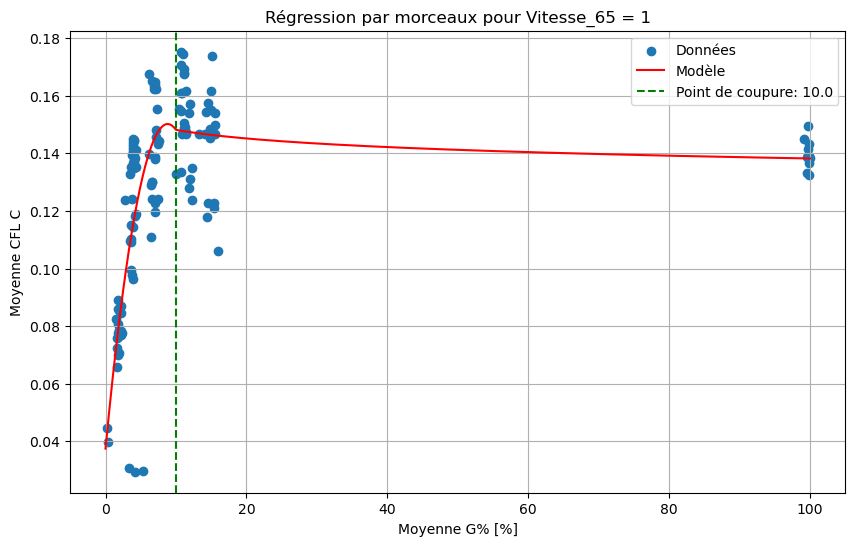

CPU times: total: 1.11 s
Wall time: 1.1 s


In [12]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)

    
    return mean_squared_error(y, y_pred) 


data = nfb
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_nfb)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=13)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(10,11, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01,]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attepmt 2

Meilleur point de coupure: 11.666666666666666
Paramètres: a1=0.043888067995682324, b1=0.02151575740534032, c1=-0.0010284754560520631, a2=0.17505705309004346, b2=-0.008197361936840517
R² train: 0.5394957547125028
R² test: 0.8080829053637292


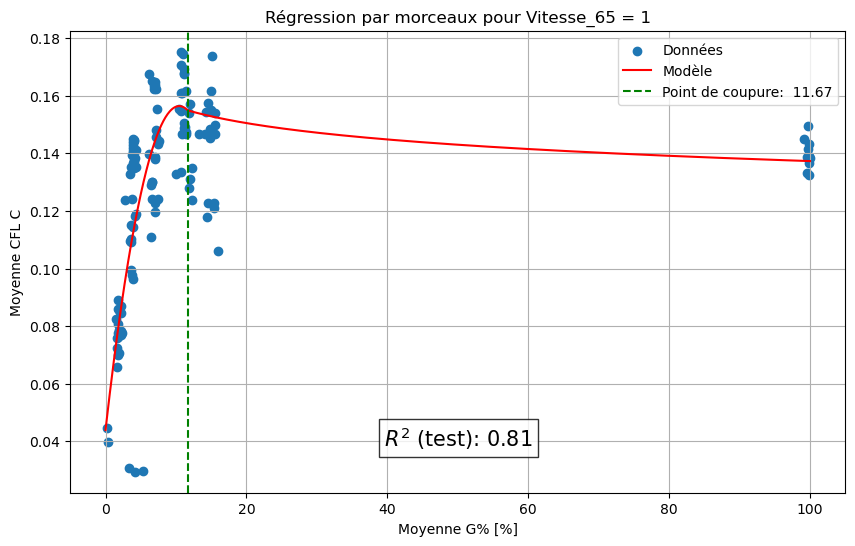

CPU times: total: 2.22 s
Wall time: 2.76 s


In [13]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + b2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred) 
    reg = 0.005 * np.sum(abs(params[3:])) + 0.0035*a1
    return mean_squared_error(y, y_pred) + 0.005*max_abscissa_diff + reg


data = nfb
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_nfb)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=13)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11,12, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, 0.01,]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  b2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +b2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k: .2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()

#### Attempt 3


Meilleur point de coupure: 11.285714285714286
Paramètres: a1=0.038834524881989116, b1=0.0211895697036052, c1=-0.0009687844342058591, a2=0.17310694774154758, b2=-0.007643576768650151
R² train: 0.5198706703412015
R² test: 0.7591603195860337


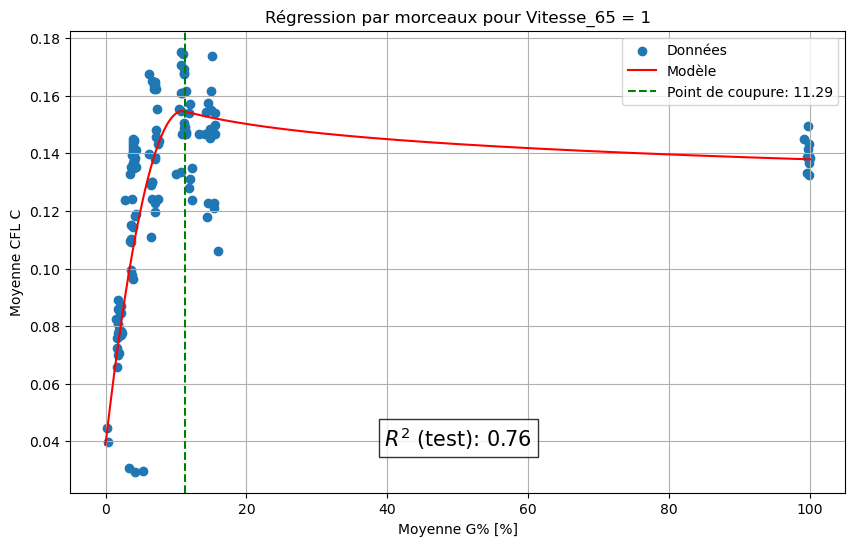

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize

# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 + b1 * glissement + c1 * (glissement**2)) - (a2 + b2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1, b1, c1, a2, b2 = params
    return a1

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1, b1, c1, a2, b2 = params
    return -b2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (b1 + 2 * c1 * glissement) - (b2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.0007 * np.sum(abs(params[3:])) + 0.003 * a1
    return mean_squared_error(y, y_pred) + 0.002 * max_abscissa_diff + reg

# Données
data = nfb
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_nfb)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=13)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11, 13, 15)  # Contraindre x_k entre 11 et 12
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.05, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1, b1, c1, a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 * (X_train['Moyenne G% [%]']**2),
                                a2 + b2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, a2, b2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                       a1 + b1 * X_test['Moyenne G% [%]'] + c1 * (X_test['Moyenne G% [%]']**2),
                       a2 + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


## Neige fraiche (G)

In [97]:
def descritisation_nfg(x):
    if x<3:
        return "3"
    elif x< 6:
        return "6"
    elif x< 9:
        return "9"
    elif x< 13:
        return "13"
    elif x< 16:
        return "16"
    else:
        return "more"

#### Attempt 1

Meilleur point de coupure: 11.0
Paramètres: a1=0.03335367439646018, b1=0.024144591838340935, c1=-0.0011688019807153868, a2=0.16995537364625485, b2=0.0, c2=-0.005186310192808194
R² train: 0.8355207918579421
R² test: 0.874603202817572


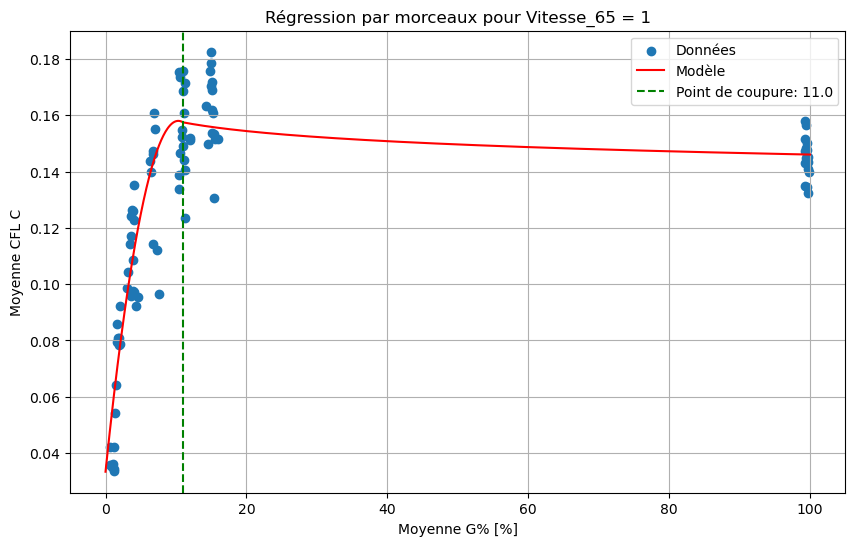

CPU times: total: 1 s
Wall time: 959 ms


In [25]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    
    return mean_squared_error(y, y_pred)


data = nfg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_nfg)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=13)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11,15, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [1, 0, 0, 1, 0, 0]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 2

Meilleur point de coupure: 13.0
Paramètres: a1=0.02806289199292669, b1=0.021056486840946718, c1=-0.0008096276183625333, a2=0.20131714370426784, b2=-0.014170646363599665
R² train: 0.8144964153902604
R² test: 0.8239226476385557


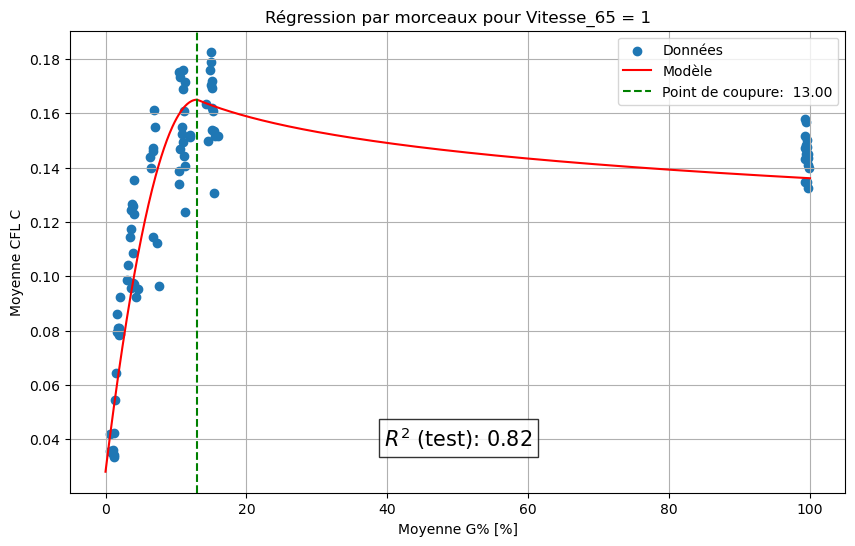

CPU times: total: 1.05 s
Wall time: 1.05 s


In [160]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + b2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred) 
    reg = 0.0003 * np.sum(abs(params[3:]))
    return mean_squared_error(y, y_pred) + 0.0005*max_abscissa_diff +reg


data = nfg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_nfg)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=2)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(13,15, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  b2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +b2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k: .2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()

#### Attempt 3

Meilleur point de coupure: 14.0
Paramètres: a1=0.03764144571852409, b1=0.018510537741137877, c1=-0.0006810101703703983, a2=0.1839179500977835, b2=-0.007808458409313652
R² train: 0.8351903145682031
R² test: 0.8268200618051679


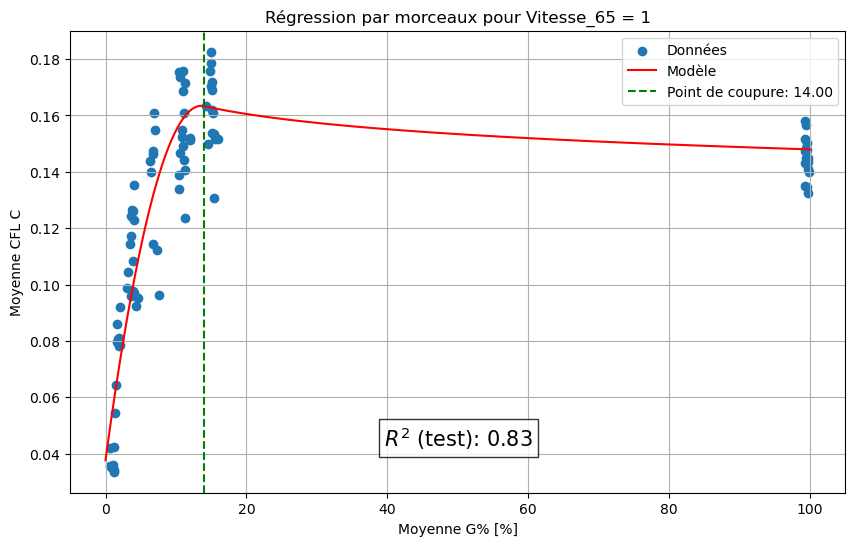

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize

# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 + b1 * glissement + c1 * (glissement**2)) - (a2 + b2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1, b1, c1, a2, b2 = params
    return a1

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1, b1, c1, a2, b2 = params
    return -b2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (b1 + 2 * c1 * glissement) - (b2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.0001 * np.sum(abs(params[3:])) +0.003*a1
    return mean_squared_error(y, y_pred) + 0.0001 * max_abscissa_diff + reg

# Données
data = nfg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_nfg)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=2)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(14, 15, 15)  # Contraindre x_k entre 11 et 12
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.05, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1, b1, c1, a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 * (X_train['Moyenne G% [%]']**2),
                                a2 + b2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, a2, b2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                       a1 + b1 * X_test['Moyenne G% [%]'] + c1 * (X_test['Moyenne G% [%]']**2),
                       a2 + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


12

## N.C. (G)

In [129]:
def descritisation_ncg(x):
    if x<2:
        return "2"
    elif x< 5:
        return "5"
    elif x< 9:
        return "9"
    elif x< 12:
        return "12"
    elif x< 15:
        return "15"
    elif x< 17:
        return "17"
    else:
        return "more"

#### Attempt 1

Meilleur point de coupure: 11.5
Paramètres: a1=-0.005563672331995728, b1=0.0324571667730357, c1=-0.001256598736166424, a2=0.23235853544764645, b2=0.0, c2=-0.012631281431126079
R² train: 0.8413638638483784
R² test: 0.8126492064701251


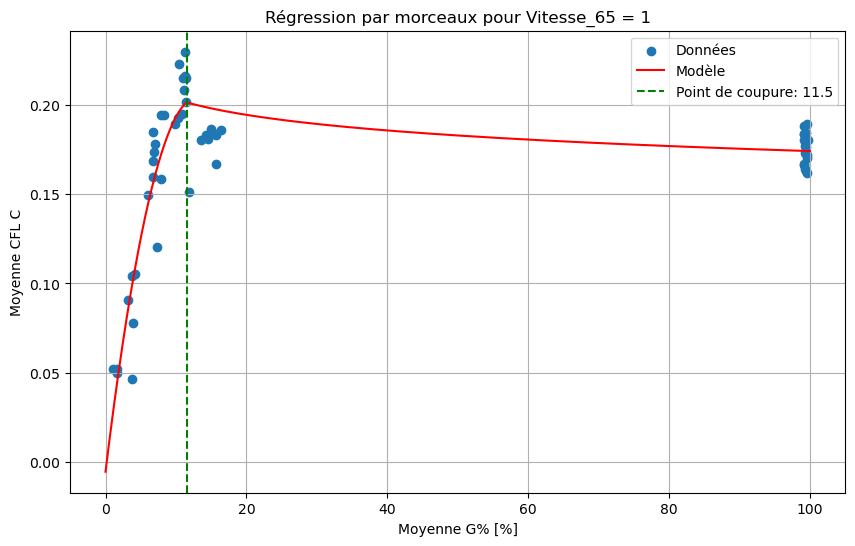

CPU times: total: 750 ms
Wall time: 735 ms


In [277]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    
    return mean_squared_error(y, y_pred)


data = ncg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_ncg)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=2)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11.5,13, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [1, 0, 0, 1, 0, 0]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 2

Meilleur point de coupure: 12.5
Paramètres: a1=-0.02825956424868745, b1=0.04074576653580479, c1=-0.0018153140831699281, a2=0.2266824071396478, b2=-0.001, c2=-0.011585850782123642
R² train: 0.8187695439791368
R² test: 0.8791382317809338


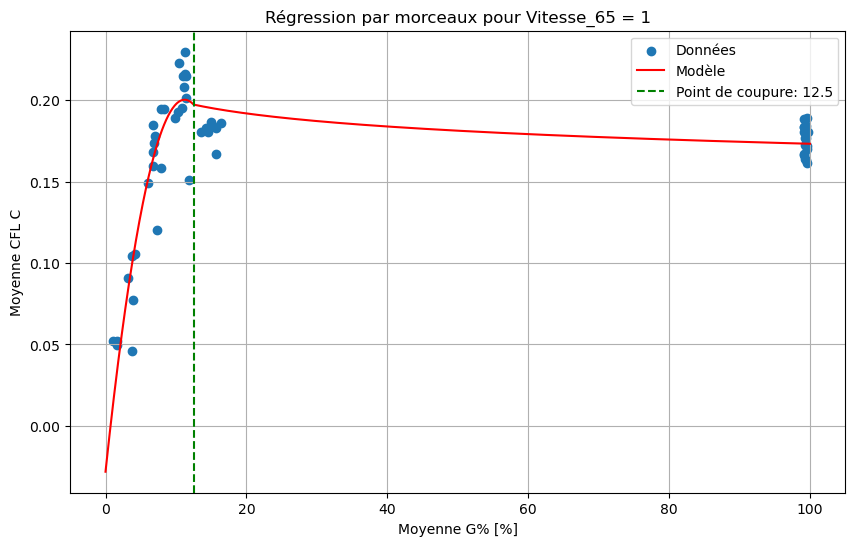

CPU times: total: 4.22 s
Wall time: 4.21 s


In [527]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.001 * np.sum(abs(params[:3])) - 0.003*abs(a1)
    
    return mean_squared_error(y, y_pred) + 0.004*max_abscissa_diff +reg


data = ncg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_ncg)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=40)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11.5,12.5, 20)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 3

Meilleur point de coupure: 12.357142857142858
Paramètres: a1=0.002568608600719364, b1=0.03163156891124646, c1=-0.0013057265133770207, a2=0.21389962372505267, b2=-0.007890396605252613
R² train: 0.8228915260682802
R² test: 0.8719281415912592


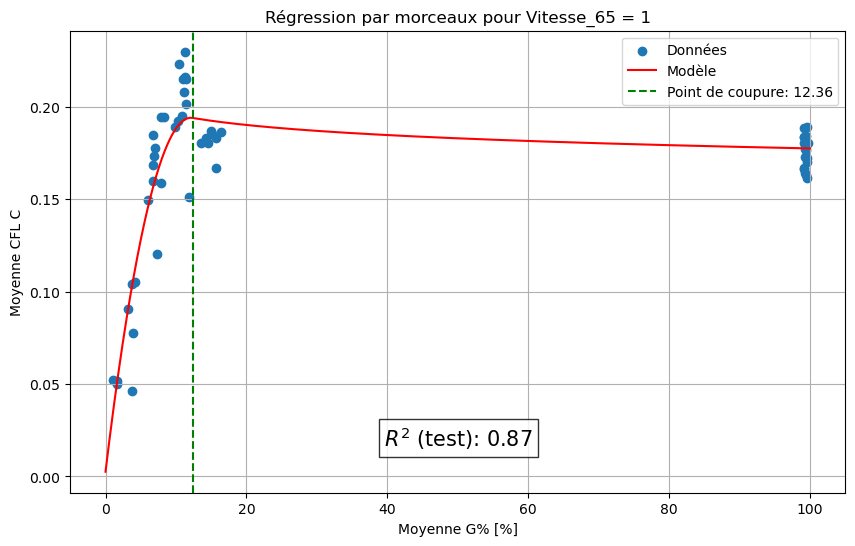

In [153]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize

# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 + b1 * glissement + c1 * (glissement**2)) - (a2 + b2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1, b1, c1, a2, b2 = params
    return a1

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1, b1, c1, a2, b2 = params
    return -b2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (b1 + 2 * c1 * glissement) - (b2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.0005 * np.sum(abs(params[3:])) 
    return mean_squared_error(y, y_pred) + 0.0001 * max_abscissa_diff + reg

# Données
data = ncg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncg)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=60)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(10, 13, 15)  # Contraindre x_k entre 11 et 12
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.01, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1, b1, c1, a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 * (X_train['Moyenne G% [%]']**2),
                                a2 + b2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, a2, b2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                       a1 + b1 * X_test['Moyenne G% [%]'] + c1 * (X_test['Moyenne G% [%]']**2),
                       a2 + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


## N.C. (B)

In [154]:
def descritisation_ncb(x):
    if x<2:
        return "2"
    elif x< 6:
        return "6"
    elif x< 9:
        return "9"
    elif x< 13:
        return "13"
    elif x< 16:
        return "16"
    else:
        return "more"

####  Attempt 1

Meilleur point de coupure: 11.0
Paramètres: a1=0.025497653723876718, b1=0.030257040942711557, c1=-0.0012417192040362298, a2=0.2500720681646312, b2=0.0, c2=-0.017513270173092413
R² train: 0.8626327844925739
R² test: 0.9143296568837406


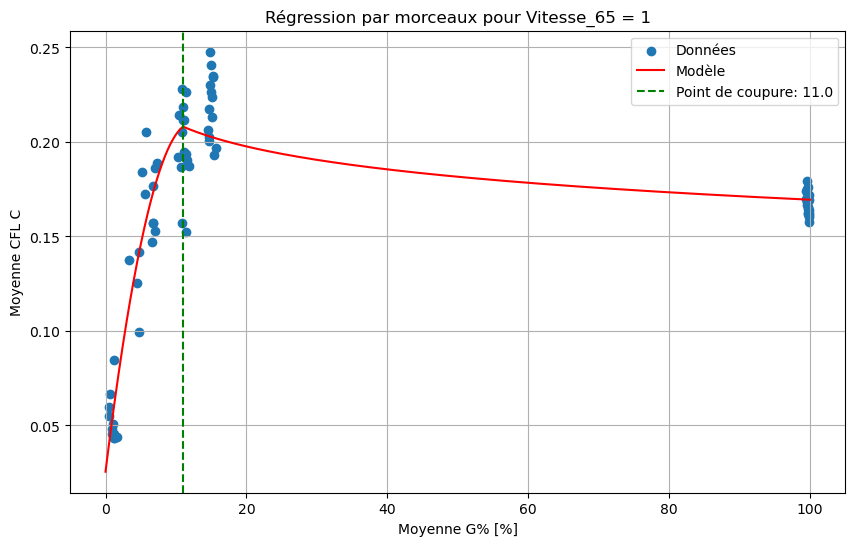

CPU times: total: 1.05 s
Wall time: 1.06 s


In [336]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    
    return mean_squared_error(y, y_pred)


data = ncb
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_ncb)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=40)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(10,11, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [1, 0, 0, 1, 0, 0]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 2

Meilleur point de coupure: 14.526315789473685
Paramètres: a1=0.03503808578233005, b1=0.024313092539158216, c1=-0.0008277744043991564, a2=0.2781307962141946, b2=-0.001, c2=-0.024135214728891883
R² train: 0.8723009412314078
R² test: 0.9240939355442013


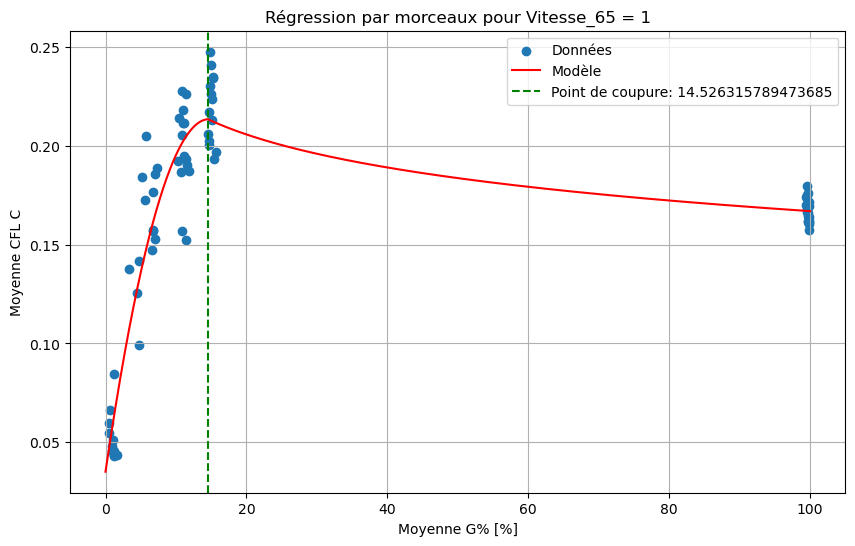

CPU times: total: 2.3 s
Wall time: 2.29 s


In [528]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.001 * np.sum(abs(params[:3]))
    
    return mean_squared_error(y, y_pred) + 0.004*max_abscissa_diff +reg


data = ncb
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_ncb)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=123)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(12,15, 20)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 3

Meilleur point de coupure: 16.105263157894736
Paramètres: a1=0.04010277101368439, b1=0.023108594341577953, c1=-0.0007661791234264065, a2=0.28383267185857736, b2=-0.025292324931847444
R² train: 0.873
R² test: 0.920


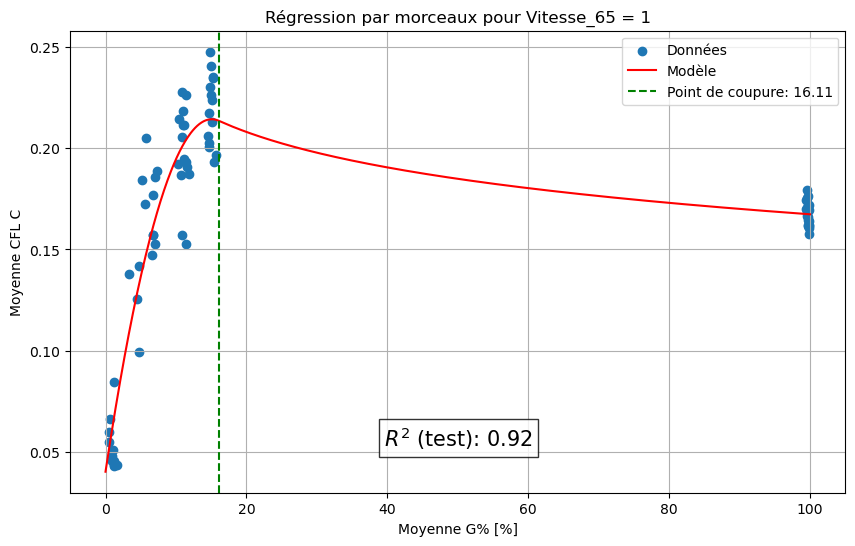

In [209]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize

# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 + b1 * glissement + c1 * (glissement**2)) - (a2 + b2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1, b1, c1, a2, b2 = params
    return a1

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1, b1, c1, a2, b2 = params
    return -b2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (b1 + 2 * c1 * glissement) - (b2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.0002 * np.sum(abs(params[3:])) +0.0025*a1
    return mean_squared_error(y, y_pred) + 0.05 * max_abscissa_diff + reg

# Données
data = ncb
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncb)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=123)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(12, 18, 20)  
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.01, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1, b1, c1, a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 * (X_train['Moyenne G% [%]']**2),
                                a2 + b2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, a2, b2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2:.3f}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                       a1 + b1 * X_test['Moyenne G% [%]'] + c1 * (X_test['Moyenne G% [%]']**2),
                       a2 + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test :.3f}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


## NC.C.


In [211]:
def descritisation_ncc(x):
    if x<2:
        return "2"
    if x<4:
        return "4"
    if x<6:
        return "6"
    elif x< 8:
        return "8"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"


#### Attempt 1

Meilleur point de coupure: 9.081632653061224
Paramètres: a1=0.022541993959605502, b1=0.04858974478471735, c1=-0.002758693073724859, a2=0.28403741393039184, b2=0.0, c2=-0.021641805505190327
R² train: 0.8307758817025812
R² test: 0.8908856835363126


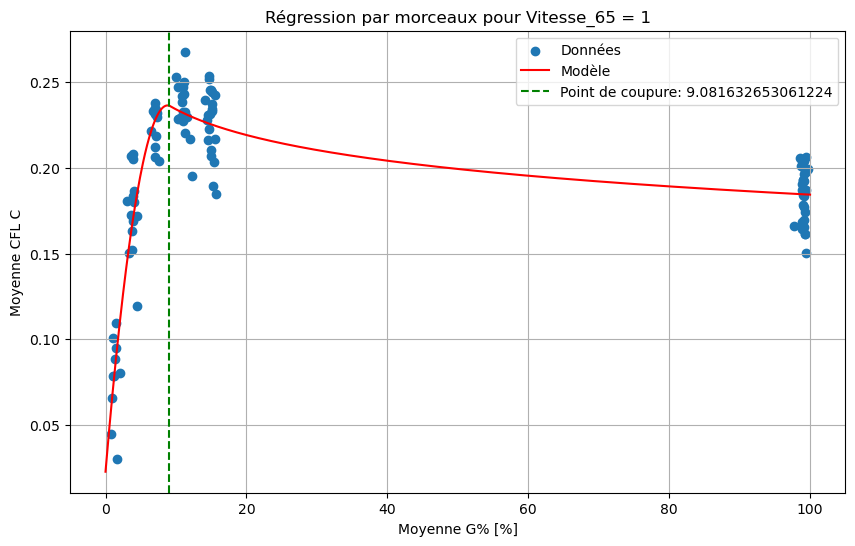

CPU times: total: 3.08 s
Wall time: 3.06 s


In [57]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    
    return mean_squared_error(y, y_pred)


data = ncc
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_ncc)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=123)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(1,100, 50)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [1, 0, 0, 1, 0, 0]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 2

Meilleur point de coupure: 13.0
Paramètres: a1=0.051245467008241584, b1=0.03435668022613107, c1=-0.0015607670831270285, a2=0.3076137185890924, b2=-0.0019087468284965956, c2=-0.02865594421061068
R² train: 0.8293307410984984
R² test: 0.7733311193297365


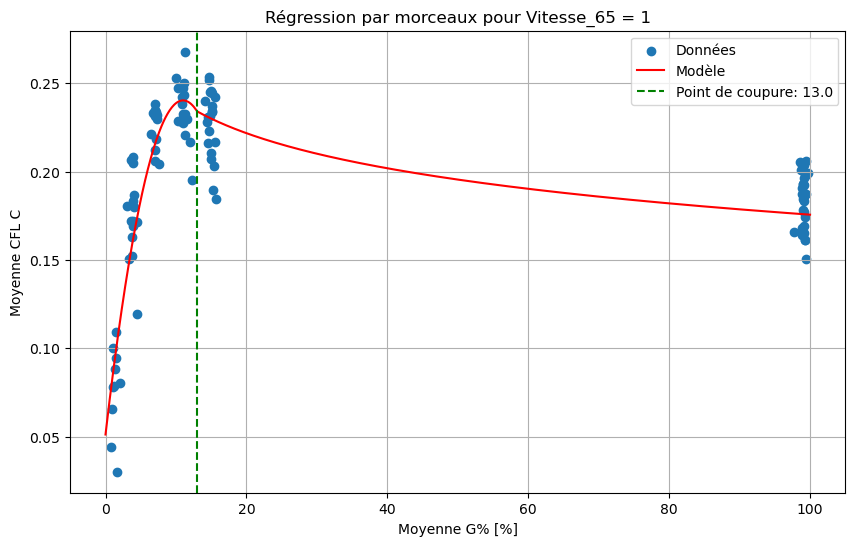

CPU times: total: 1.88 s
Wall time: 1.88 s


In [60]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.0003 * np.sum(abs(params[3:])) 
    
    return mean_squared_error(y, y_pred) + 0.004*max_abscissa_diff+reg


data = ncc
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_ncc)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=30)
# 30 75 5
# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11,13, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 3

Meilleur point de coupure: 11.105263157894736
Paramètres: a1=0.03508575425469049, b1=0.03899523192012726, c1=-0.0018510181313859083, a2=0.296451962102173, b2=-0.023508231820731366
R² train: 0.818
R² test: 0.829


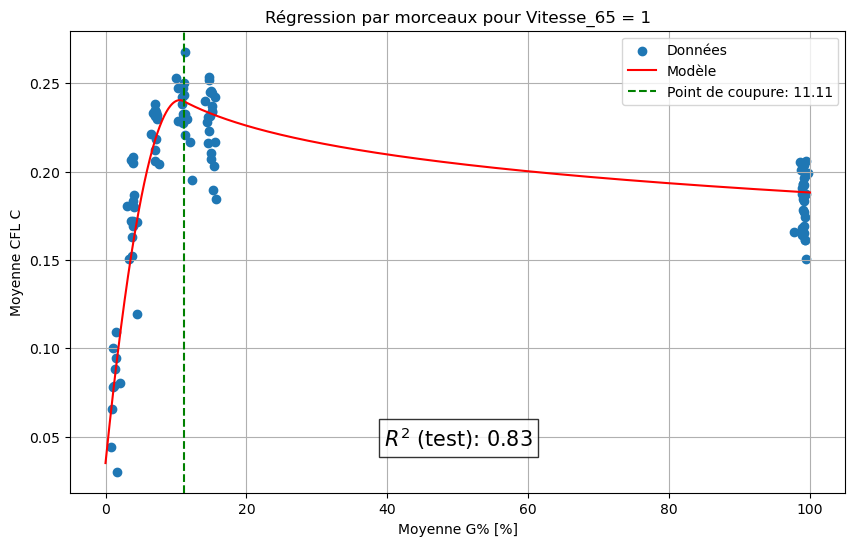

In [228]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize

# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 + b1 * glissement + c1 * (glissement**2)) - (a2 + b2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1, b1, c1, a2, b2 = params
    return a1

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1, b1, c1, a2, b2 = params
    return -b2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (b1 + 2 * c1 * glissement) - (b2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.0003 * np.sum(abs(params[3:])) +0.0025*a1
    return mean_squared_error(y, y_pred) + 0.0005 * max_abscissa_diff + reg

# Données
data = ncc
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncc)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=53)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11, 13, 20)  
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.01, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1, b1, c1, a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 * (X_train['Moyenne G% [%]']**2),
                                a2 + b2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, a2, b2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2:.3f}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                       a1 + b1 * X_test['Moyenne G% [%]'] + c1 * (X_test['Moyenne G% [%]']**2),
                       a2 + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test :.3f}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


## Verglas

In [245]:
def descritisation_verglas(x):
    if x< 6:
        return "8"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

#### Attempt 1

Meilleur point de coupure: 15.0
Paramètres: a1=0.07158898989047788, b1=0.0089200043571719, c1=-0.00024945898268429, a2=0.1843691562481815, b2=0.0, c2=-0.012964446556882888
R² train: 0.6988364898150607
R² test: 0.4958825632102636


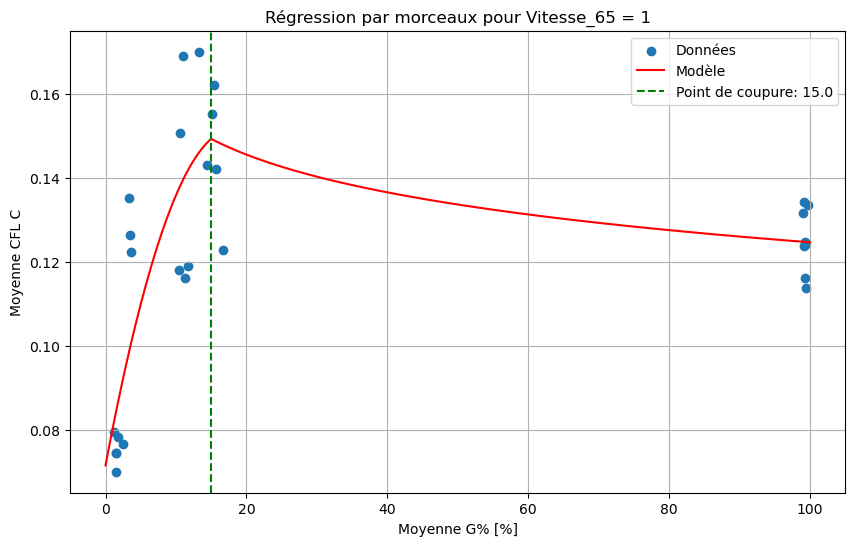

CPU times: total: 1.02 s
Wall time: 1.03 s


In [537]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    
    return mean_squared_error(y, y_pred)


data = ver
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_nfb)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=64)#  36  57 64 

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(13,15, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [1, 0, 0, 1, 0, 0]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 2

Meilleur point de coupure: 14.444444444444445
Paramètres: a1=0.07285607379567761, b1=0.010551750533673753, c1=-0.000392172963746611, a2=0.17012517760376106, b2=-0.001, c2=-0.009990852192722532
R² train: 0.606955121113194
R² test: 0.7961266945294264


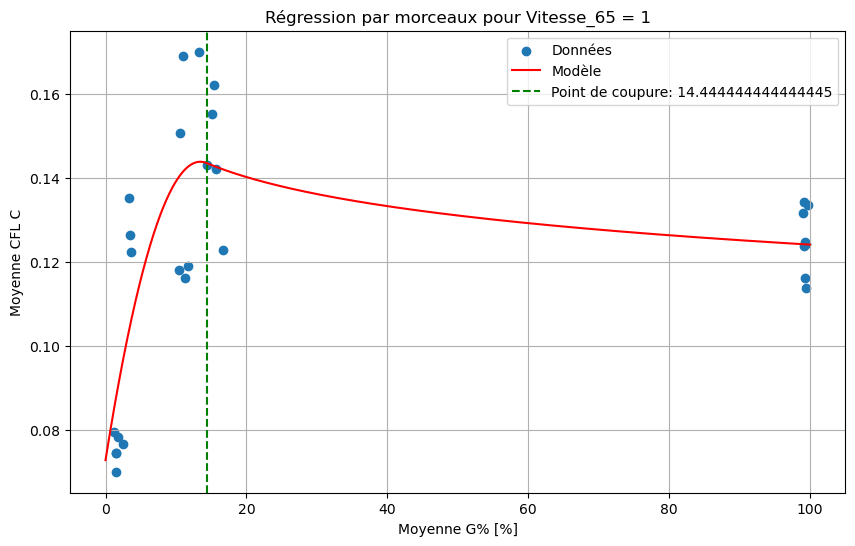

CPU times: total: 2.28 s
Wall time: 2.29 s


In [540]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.0005 * np.sum(abs(params[3:])) 
    
    return mean_squared_error(y, y_pred) + 0.004*max_abscissa_diff


data = ver
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_verglas)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=19)# 19 20 61
# 
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(10,15, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 3

Meilleur point de coupure: 14.052631578947368
Paramètres: a1=0.06773914842864878, b1=0.011674721975474358, c1=-0.00044008605785673125, a2=0.17066761575067865, b2=-0.009752701871229563
R² train: 0.633
R² test: 0.807


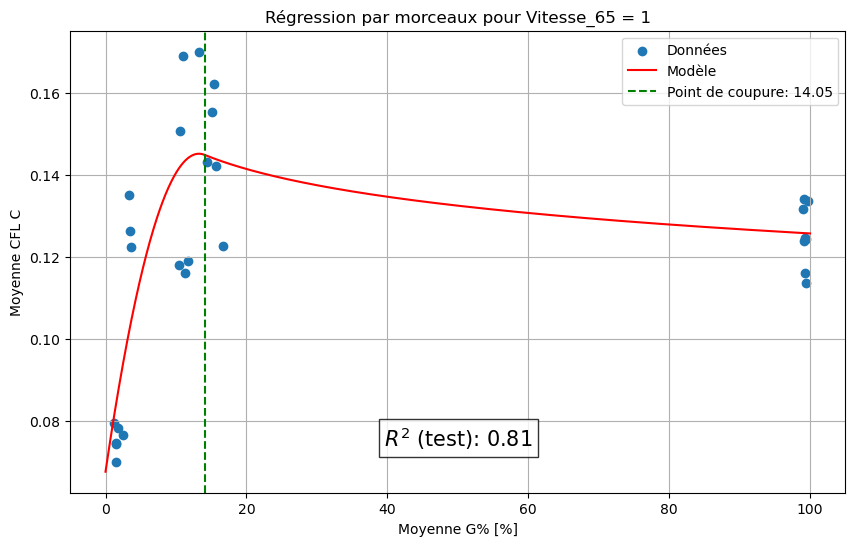

In [286]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize

# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 + b1 * glissement + c1 * (glissement**2)) - (a2 + b2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1, b1, c1, a2, b2 = params
    return a1

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1, b1, c1, a2, b2 = params
    return -b2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (b1 + 2 * c1 * glissement) - (b2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.01 * np.sum(abs(params[1:3]))+0.0005 * np.sum(abs(params[3:])) +0.002*a1
    return mean_squared_error(y, y_pred) + 0.005 * max_abscissa_diff +reg

# Données
data = ver
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_verglas)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=17)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(13, 18, 20)  
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.01, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1, b1, c1, a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 * (X_train['Moyenne G% [%]']**2),
                                a2 + b2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, a2, b2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2:.3f}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                       a1 + b1 * X_test['Moyenne G% [%]'] + c1 * (X_test['Moyenne G% [%]']**2),
                       a2 + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test :.3f}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


## Glace

In [287]:
def descritisation_glace(x):
    if x< 6:
        return "8"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

#### Attempt 1

Meilleur point de coupure: 13.0
Paramètres: a1=-0.02797195493212994, b1=0.017930166754697913, c1=-0.0006171967268662924, a2=0.15055257820262813, b2=0.0, c2=-0.01939165466147937
R² train: 0.7690039952497825
R² test: 0.853580981957648


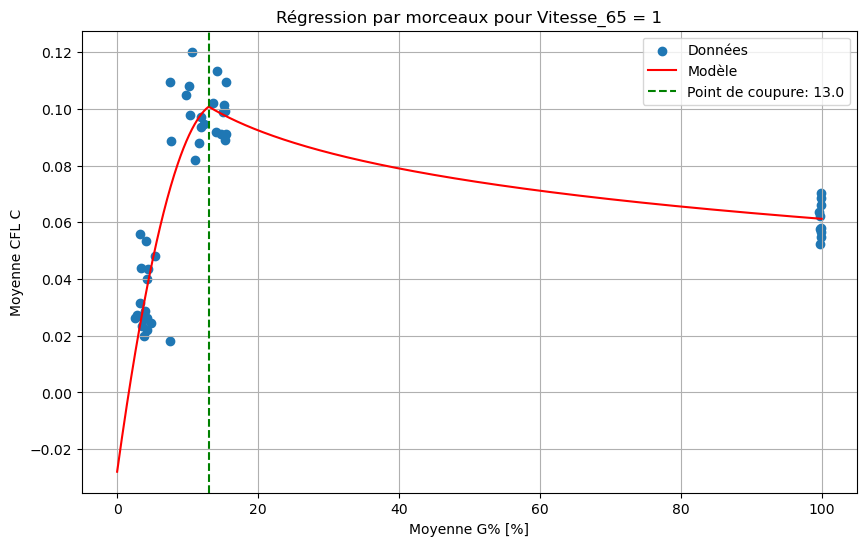

CPU times: total: 4.48 s
Wall time: 4.46 s


In [27]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    
    return mean_squared_error(y, y_pred)


data = gla
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_glace)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=40)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(13,100, 100)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [1, 0, 0, 1, 0, 0]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 2

Meilleur point de coupure: 12.11111111111111
Paramètres: a1=-0.033408299143142174, b1=0.021203352603202837, c1=-0.0008738861824291153, a2=0.1314783444990364, b2=-48.4368513423654, c2=-0.014542684248916431
R² train: 0.7399234908102423
R² test: 0.8795309878470609


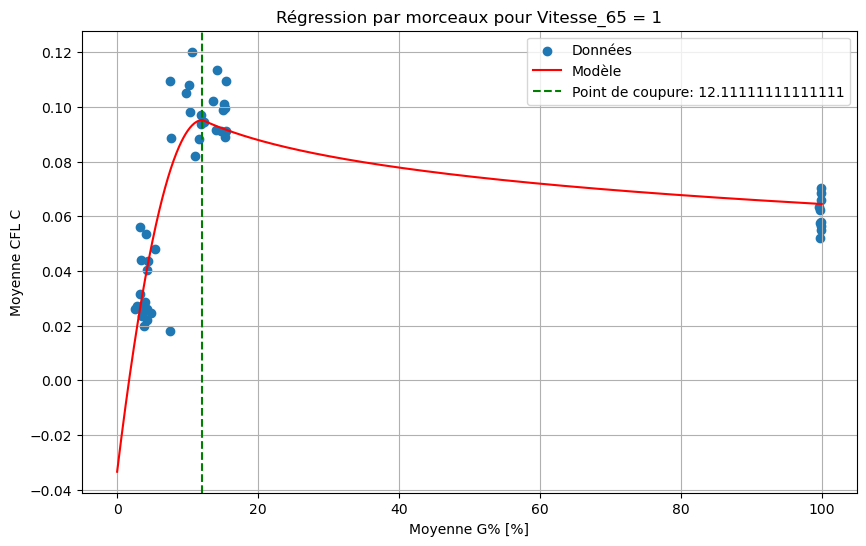

CPU times: total: 8.11 s
Wall time: 8.11 s


In [40]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.0020 * np.sum(abs(params[3:]))
    
    return mean_squared_error(y, y_pred) + 0.003*max_abscissa_diff + reg


data = gla
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_glace)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=0)# 19 20 61
# 40 0 11 26c0.002 90
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11,13, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 3

Meilleur point de coupure: 17.0
Paramètres: a1=-5.816177442359791e-16, b1=0.0124112502640664, c1=-0.00039814354134603397, a2=0.1501433267763277, b2=-0.019135712409521187
R² train: 0.734
R² test: 0.865


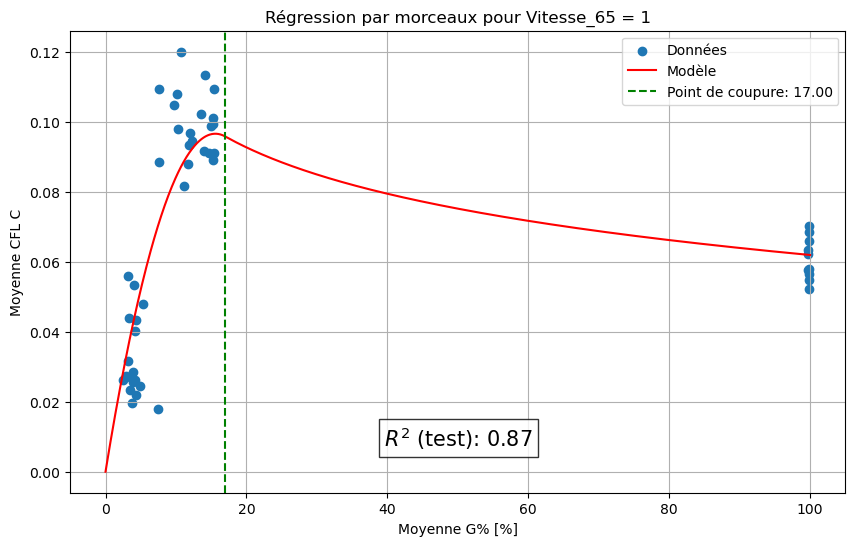

In [331]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize

# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 + b1 * glissement + c1 * (glissement**2)) - (a2 + b2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1, b1, c1, a2, b2 = params
    return a1

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1, b1, c1, a2, b2 = params
    return -b2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (b1 + 2 * c1 * glissement) - (b2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.0055 * np.sum(abs(params[1:3]))+0.0001 * np.sum(abs(params[3:])) + a1
    return mean_squared_error(y, y_pred) + 0.001 * max_abscissa_diff +reg

# Données
data = gla
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_glace)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=123)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11, 17, 20)  
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.01, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1, b1, c1, a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 * (X_train['Moyenne G% [%]']**2),
                                a2 + b2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, a2, b2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2:.3f}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                       a1 + b1 * X_test['Moyenne G% [%]'] + c1 * (X_test['Moyenne G% [%]']**2),
                       a2 + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test :.3f}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


## slush

In [332]:
def descritisation_slh(x):
    if x<0.5:
        return "0.5"
    if x<1:
        return "1"
    if x<4:
        return "4"

    elif x< 14:
        return "14"
    else:
        return "more"


#### Attempt 1

Meilleur point de coupure: 15.555555555555555
Paramètres: a1=0.007668129105366956, b1=0.013618740616328704, c1=-0.0003761994192025076, a2=0.12007179833609881, b2=0.0, c2=0.0030652899532900195
R² train: 0.7345201110436284
R² test: 0.7289014280129463


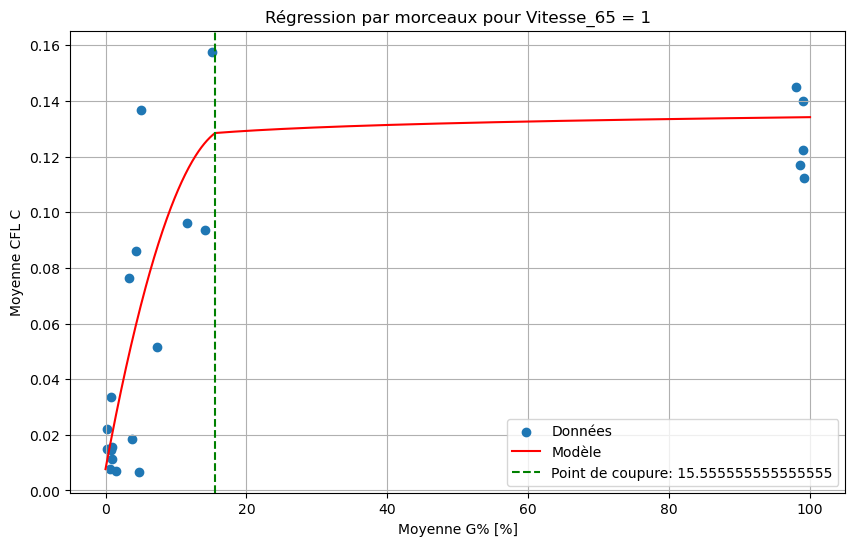

CPU times: total: 812 ms
Wall time: 817 ms


In [516]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    
    return mean_squared_error(y, y_pred)


data = slh
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_slh)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=68)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(14,16, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [1, 0, 0, 1, 0, 0]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 2

Meilleur point de coupure: 12.777777777777779
Paramètres: a1=0.011007034968593165, b1=0.012213285615798595, c1=-0.000465400338150339, a2=0.05262467137019173, b2=0.014940675925267308, c2=0.015093707662323525
R² train: 0.703712528625986
R² test: 0.7028763626986025


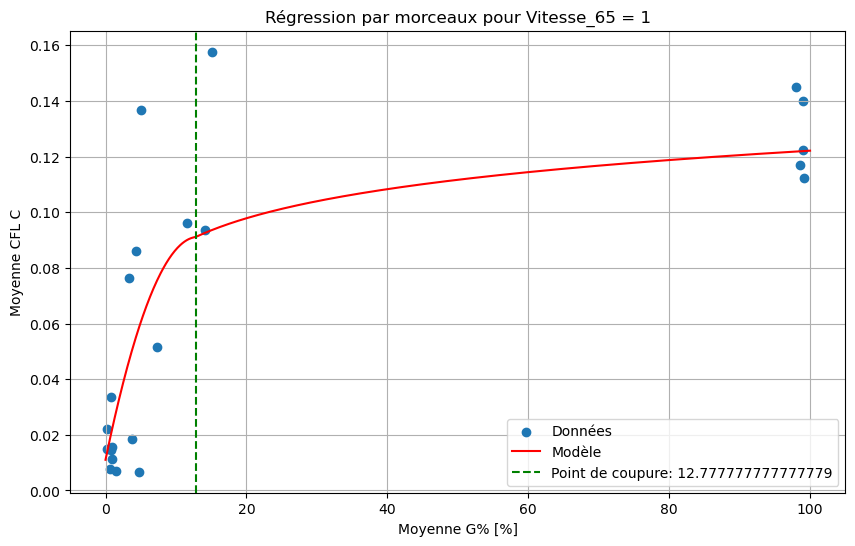

CPU times: total: 1.56 s
Wall time: 1.56 s


In [518]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.0020 * np.sum(abs(params[3:])) 
    
    return mean_squared_error(y, y_pred) + 0.003*max_abscissa_diff + reg


data = slh
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_slh)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=0)# 19 20 61
# 40 0 11 26c0.002 90
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11,13, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

#### Attempt 3

Meilleur point de coupure: 15.0
Paramètres: a1=0.005491718931275806, b1=0.012319185280966882, c1=-0.0003878847645289846, a2=0.07527598002760713, b2=0.01023963517646813
R² train: 0.695
R² test: 0.759


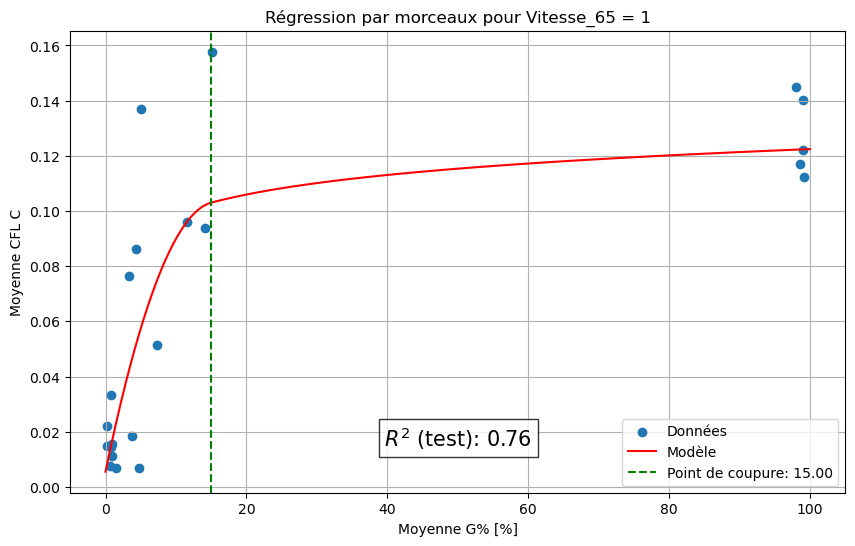

In [371]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize

# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 + b1 * glissement + c1 * (glissement**2)) - (a2 + b2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1, b1, c1, a2, b2 = params
    return a1

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1, b1, c1, a2, b2 = params
    return b2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (b1 + 2 * c1 * glissement) - (b2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.000 * np.sum(abs(params[1:]))+ 0.005*a1
    return mean_squared_error(y, y_pred)  +reg

# Données
data = slh
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_slh)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=0)
# 40 0 11 26c0.002 90

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(15, 18, 20)  
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.01, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1, b1, c1, a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 * (X_train['Moyenne G% [%]']**2),
                                a2 + b2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, a2, b2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2:.3f}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                       a1 + b1 * X_test['Moyenne G% [%]'] + c1 * (X_test['Moyenne G% [%]']**2),
                       a2 + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test :.3f}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


En definissant les contraintes, pour la troisieme et celle qui declare que le minimum apres le point de coupure doit etre au glissement consigne 100% on a fait un exeption pour le slush, c'est à dire le maximum de la courbe doit etre au glissement consigne 100% et le modele apres le point de coupure doit etre croissant.

Pour les formules des modeles precedents, pour les valeurs reelles des coeficients, ils sont de 18 chiffres apres la virgules, mais pour des raisons de clarté on n'a pris qu'une precision de 10e-5